# Assessment 3: SQLite Database Persistence

This notebook stores the cleaned weather and electricity dataset from Assessment 4 in a normalised SQLite database. The database is then used for SQL join queries and database views.

#### 1. Student name: 
#### 1. Student ID: 
#### 1. Responsible for content: Schema Definition; Queries 1, 2, 3; DB view 1.

#### 2. Student name: Tilly
#### 2. Student ID: 
#### 2. Responsible for content: DB Population; Queries 4, 5, 6; DB view 2.

# 1. Import library, data and check

In [1]:
import os
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
!pip install ipython-sql
%matplotlib inline

In [2]:
# Load the SQL extension used in the SQL lectures
%load_ext sql
%config SqlMagic.style = '_DEPRECATED_DEFAULT'

In [3]:
# File paths
csv_path = "weather_electricity_cleaned.csv"
db_path = "a3_electricity_weather.db"

# Start with a clean SQLite database each time the notebook is run
if os.path.exists(db_path):
    os.remove(db_path)
    print("Existing database removed.")
else:
    print("No existing database found. A new one will be created.")

No existing database found. A new one will be created.


In [4]:
# Read the cleaned dataset prepared in Assessment 4
df = pd.read_csv(csv_path)
df["date"] = pd.to_datetime(df["date"])

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (5535, 22)


,date,temp_mean,temp_max,temp_min,precipitation,rain,wind_speed,humidity,node,place,...,name,demand_gwh,total_electricity_value,year,month,month_name,weekday,season,price_rank,high_price_flag
0,2023-01-01,19.0,21.1,17.3,0.0,0.0,21.5,66,ALB0331,"Albany, Auckland",...,ALB0331 - Albany,1.231,5219.45,2023,1,Jan,Sunday,Summer,5255.0,Other
1,2023-01-02,18.3,19.9,17.0,3.0,3.0,30.3,70,ALB0331,"Albany, Auckland",...,ALB0331 - Albany,1.284,14559.46,2023,1,Jan,Monday,Summer,5004.0,Other
2,2023-01-03,18.9,20.6,17.6,3.4,3.4,34.6,77,ALB0331,"Albany, Auckland",...,ALB0331 - Albany,1.327,69051.80,2023,1,Jan,Tuesday,Summer,4021.0,Other
3,2023-01-04,18.5,19.6,17.7,28.1,28.1,41.8,89,ALB0331,"Albany, Auckland",...,ALB0331 - Albany,1.440,71794.71,2023,1,Jan,Wednesday,Summer,3989.0,Other
4,2023-01-05,19.4,20.1,18.7,32.7,32.7,38.5,93,ALB0331,"Albany, Auckland",...,ALB0331 - Albany,1.487,79382.47,2023,1,Jan,Thursday,Summer,3888.0,Other


In [5]:
# Check column names and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5535 entries, 0 to 5534
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   date                     5535 non-null   datetime64[ns]
 1   temp_mean                5535 non-null   float64       
 2   temp_max                 5535 non-null   float64       
 3   temp_min                 5535 non-null   float64       
 4   precipitation            5535 non-null   float64       
 5   rain                     5535 non-null   float64       
 6   wind_speed               5535 non-null   float64       
 7   humidity                 5535 non-null   int64         
 8   node                     5535 non-null   object        
 9   place                    5535 non-null   object        
 10  latitude                 5535 non-null   float64       
 11  longitude                5535 non-null   float64       
 12  name                     5485 non-

In [6]:
# Check missing values
missing_summary = df.isna().sum().reset_index()
missing_summary.columns = ["column", "missing_count"]
missing_summary

,column,missing_count
0,date,0
1,temp_mean,0
2,temp_max,0
3,temp_min,0
4,precipitation,0
5,rain,0
6,wind_speed,0
7,humidity,0
8,node,0
9,place,0


In [7]:
# The name column has some missing values in the cleaned CSV.
print("Seasons:", sorted(df["season"].unique()))
print("Weekdays:", sorted(df["weekday"].unique()))
print("High price flags:", sorted(df["high_price_flag"].unique()))

Seasons: ['Autumn', 'Spring', 'Summer', 'Winter']
Weekdays: ['Friday', 'Monday', 'Saturday', 'Sunday', 'Thursday', 'Tuesday', 'Wednesday']
High price flags: ['Other', 'Top 5%']


# 2. Schema Definition

The schema contains two dimension tables and four observation tables.

- **locations** stores node and geographic information.
- **dates** stores date-related attributes.
- **electricity_observations** stores electricity demand, total electricity value, price rank, and high price flag.
- **temperature_observations** stores mean, maximum, and minimum temperature.
- **rainfall_observations** stores precipitation and rain.
- **wind_humidity_observations** stores wind speed and humidity.

The four observation tables use **date_id** and **location_id** together as a composite primary key. This is because each location should have only one observation for each date.

In [8]:
# Display the database schema image
display(Image("weather_electricity_schema.png"))

FileNotFoundError: No such file or directory: 'weather_electricity_schema.png'

FileNotFoundError: No such file or directory: 'weather_electricity_schema.png'

<IPython.core.display.Image object>

In [9]:
# Prepare locations table
locations = (
    df[["node", "place", "latitude", "longitude", "name"]]
    .sort_values(["node", "name"])
    .drop_duplicates(subset=["node"], keep="first")
    .reset_index(drop=True)
)

locations["location_id"] = locations.index + 1

locations = locations[[
    "location_id",
    "node",
    "place",
    "latitude",
    "longitude",
    "name"
]]

locations

,location_id,node,place,latitude,longitude,name
0,1,ALB0331,"Albany, Auckland",-36.7285,174.7072,ALB0331 - Albany
1,2,HAM0331,Hamilton,-37.7870,175.2793,HAM0331 - Hamilton
2,3,HEN0331,"Henderson, Auckland",-36.8810,174.6300,HEN0331 - Henderson
3,4,PEN0331,"Penrose, Auckland",-36.9100,174.8150,PEN0331 - Penrose
4,5,ROT0111,Rotorua,-38.1368,176.2497,ROT0111 - Rotorua


In [10]:
# Prepare dates table
dates = df[["date", "year", "month", "month_name", "weekday", "season"]].drop_duplicates().reset_index(drop=True)
dates["date_id"] = dates.index + 1
dates["date"] = dates["date"].dt.strftime("%Y-%m-%d")

dates = dates[[
    "date_id",
    "date",
    "year",
    "month",
    "month_name",
    "weekday",
    "season"
]]

dates.head()

,date_id,date,year,month,month_name,weekday,season
0,1,2023-01-01,2023,1,Jan,Sunday,Summer
1,2,2023-01-02,2023,1,Jan,Monday,Summer
2,3,2023-01-03,2023,1,Jan,Tuesday,Summer
3,4,2023-01-04,2023,1,Jan,Wednesday,Summer
4,5,2023-01-05,2023,1,Jan,Thursday,Summer


In [11]:
# Add primary keys back into the main dataframe for table population
df_for_db = df.copy()
df_for_db["date"] = df_for_db["date"].dt.strftime("%Y-%m-%d")

df_for_db = df_for_db.merge(
    locations[["location_id", "node"]],
    on="node",
    how="left"
)

df_for_db = df_for_db.merge(
    dates[["date_id", "date"]],
    on="date",
    how="left"
)

df_for_db.head()

,date,temp_mean,temp_max,temp_min,precipitation,rain,wind_speed,humidity,node,place,...,total_electricity_value,year,month,month_name,weekday,season,price_rank,high_price_flag,location_id,date_id
0,2023-01-01,19.0,21.1,17.3,0.0,0.0,21.5,66,ALB0331,"Albany, Auckland",...,5219.45,2023,1,Jan,Sunday,Summer,5255.0,Other,1,1
1,2023-01-02,18.3,19.9,17.0,3.0,3.0,30.3,70,ALB0331,"Albany, Auckland",...,14559.46,2023,1,Jan,Monday,Summer,5004.0,Other,1,2
2,2023-01-03,18.9,20.6,17.6,3.4,3.4,34.6,77,ALB0331,"Albany, Auckland",...,69051.80,2023,1,Jan,Tuesday,Summer,4021.0,Other,1,3
3,2023-01-04,18.5,19.6,17.7,28.1,28.1,41.8,89,ALB0331,"Albany, Auckland",...,71794.71,2023,1,Jan,Wednesday,Summer,3989.0,Other,1,4
4,2023-01-05,19.4,20.1,18.7,32.7,32.7,38.5,93,ALB0331,"Albany, Auckland",...,79382.47,2023,1,Jan,Thursday,Summer,3888.0,Other,1,5


In [12]:
# Prepare electricity observations table
electricity_observations = df_for_db[[
    "date_id",
    "location_id",
    "demand_gwh",
    "total_electricity_value",
    "price_rank",
    "high_price_flag"
]].copy()

electricity_observations.head()

,date_id,location_id,demand_gwh,total_electricity_value,price_rank,high_price_flag
0,1,1,1.231,5219.45,5255.0,Other
1,2,1,1.284,14559.46,5004.0,Other
2,3,1,1.327,69051.80,4021.0,Other
3,4,1,1.440,71794.71,3989.0,Other
4,5,1,1.487,79382.47,3888.0,Other


In [13]:
# Prepare temperature observations table
temperature_observations = df_for_db[[
    "date_id",
    "location_id",
    "temp_mean",
    "temp_max",
    "temp_min"
]].copy()

temperature_observations.head()

,date_id,location_id,temp_mean,temp_max,temp_min
0,1,1,19.0,21.1,17.3
1,2,1,18.3,19.9,17.0
2,3,1,18.9,20.6,17.6
3,4,1,18.5,19.6,17.7
4,5,1,19.4,20.1,18.7


In [14]:
# Prepare rainfall observations table
rainfall_observations = df_for_db[[
    "date_id",
    "location_id",
    "precipitation",
    "rain"
]].copy()

rainfall_observations.head()

,date_id,location_id,precipitation,rain
0,1,1,0.0,0.0
1,2,1,3.0,3.0
2,3,1,3.4,3.4
3,4,1,28.1,28.1
4,5,1,32.7,32.7


In [15]:
# Prepare wind and humidity observations table
wind_humidity_observations = df_for_db[[
    "date_id",
    "location_id",
    "wind_speed",
    "humidity"
]].copy()

wind_humidity_observations.head()

,date_id,location_id,wind_speed,humidity
0,1,1,21.5,66
1,2,1,30.3,70
2,3,1,34.6,77
3,4,1,41.8,89
4,5,1,38.5,93


## Create the SQLite database and tables

In [16]:
# Connect to the SQLite database using the SQL magic style used in the lectures
%sql sqlite:///a3_electricity_weather.db

In [17]:
# Enable foreign key constraint checking
%sql PRAGMA foreign_keys = ON;

 * sqlite:///a3_electricity_weather.db
Done.


[]

In [18]:
%%sql

CREATE TABLE locations (
    location_id INTEGER NOT NULL UNIQUE,
    node TEXT NOT NULL UNIQUE,
    place TEXT NOT NULL,
    latitude REAL NOT NULL,
    longitude REAL NOT NULL,
    name TEXT NOT NULL,
    PRIMARY KEY (location_id)
);

CREATE TABLE dates (
    date_id INTEGER NOT NULL UNIQUE,
    date TEXT NOT NULL UNIQUE,
    year INTEGER NOT NULL,
    month INTEGER NOT NULL CHECK (month BETWEEN 1 AND 12),
    month_name TEXT NOT NULL,
    weekday TEXT NOT NULL CHECK (weekday IN (
        'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
    )),
    season TEXT NOT NULL CHECK (season IN ('Summer', 'Autumn', 'Winter', 'Spring')),
    PRIMARY KEY (date_id)
);

CREATE TABLE electricity_observations (
    date_id INTEGER NOT NULL,
    location_id INTEGER NOT NULL,
    demand_gwh REAL NOT NULL CHECK (demand_gwh >= 0),
    total_electricity_value REAL NOT NULL CHECK (total_electricity_value >= 0),
    price_rank REAL NOT NULL CHECK (price_rank > 0),
    high_price_flag TEXT NOT NULL CHECK (high_price_flag IN ('Top 5%', 'Other')),
    PRIMARY KEY (date_id, location_id),
    FOREIGN KEY (date_id) REFERENCES dates(date_id),
    FOREIGN KEY (location_id) REFERENCES locations(location_id)
);

CREATE TABLE temperature_observations (
    date_id INTEGER NOT NULL,
    location_id INTEGER NOT NULL,
    temp_mean REAL NOT NULL,
    temp_max REAL NOT NULL,
    temp_min REAL NOT NULL,
    PRIMARY KEY (date_id, location_id),
    FOREIGN KEY (date_id) REFERENCES dates(date_id),
    FOREIGN KEY (location_id) REFERENCES locations(location_id),
    CHECK (temp_min <= temp_mean AND temp_mean <= temp_max)
);

CREATE TABLE rainfall_observations (
    date_id INTEGER NOT NULL,
    location_id INTEGER NOT NULL,
    precipitation REAL NOT NULL CHECK (precipitation >= 0),
    rain REAL NOT NULL CHECK (rain >= 0),
    PRIMARY KEY (date_id, location_id),
    FOREIGN KEY (date_id) REFERENCES dates(date_id),
    FOREIGN KEY (location_id) REFERENCES locations(location_id)
);

CREATE TABLE wind_humidity_observations (
    date_id INTEGER NOT NULL,
    location_id INTEGER NOT NULL,
    wind_speed REAL NOT NULL CHECK (wind_speed >= 0),
    humidity REAL NOT NULL CHECK (humidity BETWEEN 0 AND 100),
    PRIMARY KEY (date_id, location_id),
    FOREIGN KEY (date_id) REFERENCES dates(date_id),
    FOREIGN KEY (location_id) REFERENCES locations(location_id)
);

 * sqlite:///a3_electricity_weather.db
Done.
Done.
Done.
Done.
Done.
Done.


[]

In [19]:
%%sql

CREATE INDEX ix_dates_year_month ON dates(year, month);
CREATE INDEX ix_dates_season ON dates(season);
CREATE INDEX ix_dates_weekday ON dates(weekday);
CREATE INDEX ix_locations_place ON locations(place);
CREATE INDEX ix_electricity_value ON electricity_observations(total_electricity_value);
CREATE INDEX ix_electricity_flag ON electricity_observations(high_price_flag);

 * sqlite:///a3_electricity_weather.db
Done.
Done.
Done.
Done.
Done.
Done.


[]

# 3. DB Population

In [20]:
# Open a Python connection to the database
connection = sqlite3.connect("a3_electricity_weather.db")
connection.execute("PRAGMA foreign_keys = ON;")

In [21]:
# Write the prepared dataframes into the SQLite tables
locations.to_sql("locations", connection, if_exists="append", index=False)
dates.to_sql("dates", connection, if_exists="append", index=False)
electricity_observations.to_sql("electricity_observations", connection, if_exists="append", index=False)
temperature_observations.to_sql("temperature_observations", connection, if_exists="append", index=False)
rainfall_observations.to_sql("rainfall_observations", connection, if_exists="append", index=False)
wind_humidity_observations.to_sql("wind_humidity_observations", connection, if_exists="append", index=False)

connection.commit()

In [22]:
# Close the Python connection after writing the tables
connection.close()

In [23]:
%%sql row_counts <<

SELECT 'locations' AS table_name, COUNT(*) AS row_count FROM locations
UNION ALL
SELECT 'dates' AS table_name, COUNT(*) AS row_count FROM dates
UNION ALL
SELECT 'electricity_observations' AS table_name, COUNT(*) AS row_count FROM electricity_observations
UNION ALL
SELECT 'temperature_observations' AS table_name, COUNT(*) AS row_count FROM temperature_observations
UNION ALL
SELECT 'rainfall_observations' AS table_name, COUNT(*) AS row_count FROM rainfall_observations
UNION ALL
SELECT 'wind_humidity_observations' AS table_name, COUNT(*) AS row_count FROM wind_humidity_observations;

 * sqlite:///a3_electricity_weather.db
Done.
Returning data to local variable row_counts


In [24]:
row_counts_df = row_counts.DataFrame()
row_counts_df

,table_name,row_count
0,locations,5
1,dates,1107
2,electricity_observations,5535
3,temperature_observations,5535
4,rainfall_observations,5535
5,wind_humidity_observations,5535


# 4. SQLite Queries
The following SQL queries use table joins to extract analysis results from the database.

## Query 1: Temperature vs electricity value
This query checks whether electricity value changes when the temperature is different. I grouped the temperature into four bands: cold, cool, mild, and warm. Then I calculated the average temperature, average electricity demand, and average electricity value for each group.

In [25]:
%%sql query1_result <<

SELECT
    CASE
        WHEN t.temp_mean < 10 THEN 'Cold: below 10C'
        WHEN t.temp_mean >= 10 AND t.temp_mean < 15 THEN 'Cool: 10-15C'
        WHEN t.temp_mean >= 15 AND t.temp_mean < 20 THEN 'Mild: 15-20C'
        ELSE 'Warm: 20C and above'
    END AS temperature_band,
    COUNT(*) AS number_of_records,
    AVG(t.temp_mean) AS avg_temp_mean,
    AVG(e.demand_gwh) AS avg_demand_gwh,
    AVG(e.total_electricity_value) AS avg_electricity_value
FROM electricity_observations AS e
INNER JOIN temperature_observations AS t
    ON e.date_id = t.date_id
   AND e.location_id = t.location_id
INNER JOIN dates AS d
    ON e.date_id = d.date_id
GROUP BY temperature_band
ORDER BY
    CASE temperature_band
        WHEN 'Cold: below 10C' THEN 1
        WHEN 'Cool: 10-15C' THEN 2
        WHEN 'Mild: 15-20C' THEN 3
        WHEN 'Warm: 20C and above' THEN 4
    END;

 * sqlite:///a3_electricity_weather.db
Done.
Returning data to local variable query1_result


In [26]:
query1_df = query1_result.DataFrame()
query1_df

,temperature_band,number_of_records,avg_temp_mean,avg_demand_gwh,avg_electricity_value
0,Cold: below 10C,636,8.303931,1.579852,403106.337390
1,Cool: 10-15C,2128,12.690555,1.922738,327966.109784
2,Mild: 15-20C,2340,17.533590,1.742411,256563.857350
3,Warm: 20C and above,431,20.823434,2.116689,412201.906682


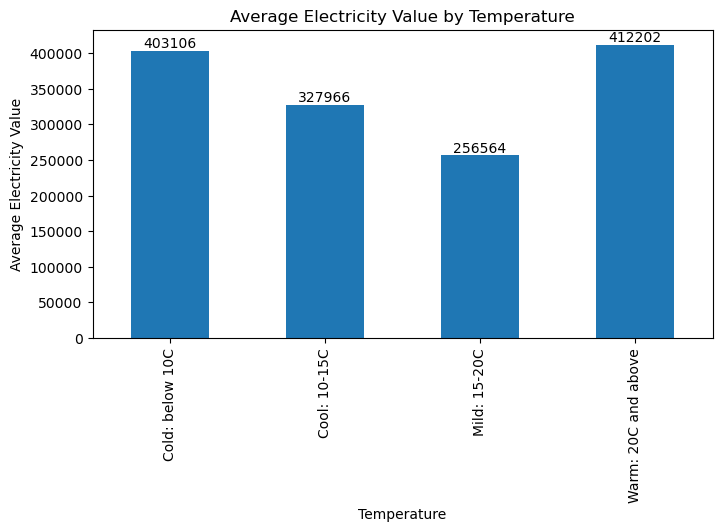

In [27]:
ax = query1_df.plot(
    x='temperature_band',
    y='avg_electricity_value',
    kind='bar',
    figsize=(8,4)
)

plt.title('Average Electricity Value by Temperature')
plt.xlabel('Temperature')
plt.ylabel('Average Electricity Value')
ax.bar_label(ax.containers[0])
plt.legend().remove()
plt.show()

From the chart, electricity value is higher in cold and warm weather. The warm group has the highest average value, about 412,202, and the cold group is also high at about 403,106. The mild group has the lowest value, about 256,673. This may mean that people use more electricity when the weather is very cold or quite warm, because heating or cooling may be needed. However, the pattern is not very strong, because the value does not simply go up or down as temperature changes.

## Query 2: Rainfall levels and electricity demand/value

This query looks at whether rainfall level is related to electricity demand and electricity value. I grouped the rain data into no rain, light rain, moderate rain, and heavy rain. Then I compared the average electricity demand and average electricity value in each rain group.

In [28]:
%%sql query2_result <<

SELECT
    CASE
        WHEN r.rain = 0 THEN 'No rain'
        WHEN r.rain > 0 AND r.rain < 2 THEN 'Light rain'
        WHEN r.rain >= 2 AND r.rain < 10 THEN 'Moderate rain'
        ELSE 'Heavy rain'
    END AS rain_band,
    COUNT(*) AS number_of_records,
    AVG(r.precipitation) AS avg_precipitation,
    AVG(r.rain) AS avg_rain,
    AVG(e.demand_gwh) AS avg_demand_gwh,
    AVG(e.total_electricity_value) AS avg_electricity_value
FROM electricity_observations AS e
INNER JOIN rainfall_observations AS r
    ON e.date_id = r.date_id
   AND e.location_id = r.location_id
INNER JOIN dates AS d
    ON e.date_id = d.date_id
GROUP BY rain_band
ORDER BY
    CASE rain_band
        WHEN 'No rain' THEN 1
        WHEN 'Light rain' THEN 2
        WHEN 'Moderate rain' THEN 3
        WHEN 'Heavy rain' THEN 4
    END;

 * sqlite:///a3_electricity_weather.db
Done.
Returning data to local variable query2_result


In [29]:
query2_df = query2_result.DataFrame()
query2_df

,rain_band,number_of_records,avg_precipitation,avg_rain,avg_demand_gwh,avg_electricity_value
0,No rain,1604,0.000000,0.000000,1.709254,328053.600580
1,Light rain,2053,0.656357,0.656357,1.928601,323206.431427
2,Moderate rain,1171,4.702391,4.702306,1.802517,275169.664406
3,Heavy rain,707,21.797171,21.792786,1.802120,311657.007228


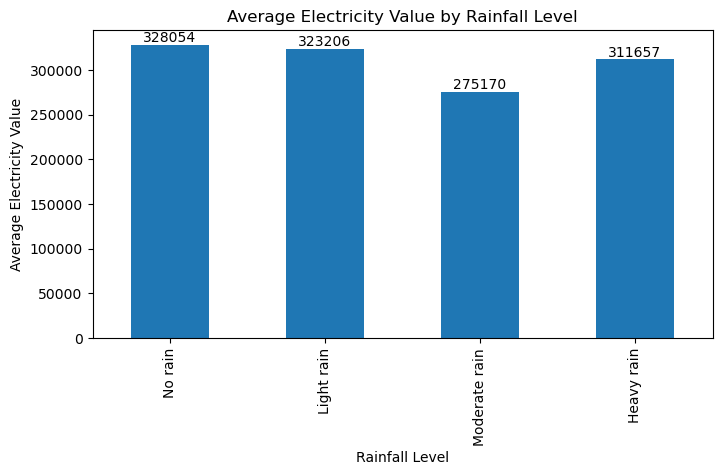

In [30]:
ax = query2_df.plot(
    x='rain_band',
    y='avg_electricity_value',
    kind='bar',
    figsize=(8,4)
)

plt.title('Average Electricity Value by Rainfall Level')
plt.xlabel('Rainfall Level')
plt.ylabel('Average Electricity Value')
ax.bar_label(ax.containers[0])
plt.legend().remove()
plt.show()

The chart shows that electricity value is quite similar for no rain, light rain, and heavy rain. No rain has the highest average value, about 328,053, while light rain is close at about 323,206. Moderate rain has the lowest value, about 275,169. This result does not show a clear pattern between rainfall and electricity value. Rainfall may have some effect, but it does not look as important as temperature or season in this data.

## Query 3: Wind and humidity compared with electricity value

This query checks if wind speed and humidity are related to electricity demand and electricity value. I grouped wind speed into three levels: low wind, medium wind, and high wind. Then I compared the average wind speed, humidity, electricity demand, and electricity value for each group.

In [31]:
%%sql query3_result <<

SELECT
    CASE
        WHEN wh.wind_speed < 10 THEN 'Low wind'
        WHEN wh.wind_speed >= 10 AND wh.wind_speed < 20 THEN 'Medium wind'
        ELSE 'High wind'
    END AS wind_speed_band,
    COUNT(*) AS number_of_records,
    AVG(wh.wind_speed) AS avg_wind_speed,
    AVG(wh.humidity) AS avg_humidity,
    AVG(e.demand_gwh) AS avg_demand_gwh,
    AVG(e.total_electricity_value) AS avg_electricity_value
FROM electricity_observations AS e
INNER JOIN wind_humidity_observations AS wh
    ON e.date_id = wh.date_id
   AND e.location_id = wh.location_id
INNER JOIN dates AS d
    ON e.date_id = d.date_id
GROUP BY wind_speed_band
ORDER BY
    CASE wind_speed_band
        WHEN 'Low wind' THEN 1
        WHEN 'Medium wind' THEN 2
        WHEN 'High wind' THEN 3
    END;

 * sqlite:///a3_electricity_weather.db
Done.
Returning data to local variable query3_result


In [32]:
query3_df = query3_result.DataFrame()
query3_df.head(20)

,wind_speed_band,number_of_records,avg_wind_speed,avg_humidity,avg_demand_gwh,avg_electricity_value
0,Low wind,1705,7.34434,82.114370,1.735021,344656.531372
1,Medium wind,2830,14.42000,80.209187,1.794895,294991.935095
2,High wind,1000,25.13340,80.798000,2.048143,309839.397870


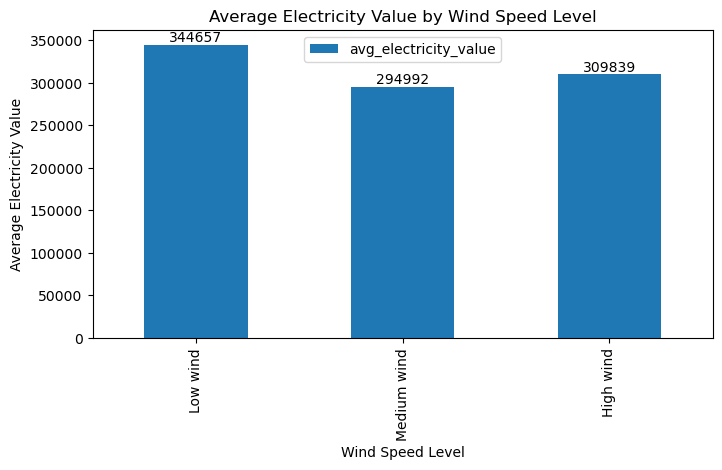

In [33]:
ax = query3_df.plot(
    x='wind_speed_band',
    y='avg_electricity_value',
    kind='bar',
    figsize=(8,4)
)

plt.title('Average Electricity Value by Wind Speed Level')
plt.xlabel('Wind Speed Level')
plt.ylabel('Average Electricity Value')
ax.bar_label(ax.containers[0])

plt.show()

From the chart, low wind has the highest average electricity value, about 344,656. Medium wind has the lowest value, about 294,992, while high wind is slightly higher at about 309,839. Overall, the result does not show a clear pattern where stronger wind leads to higher electricity value. The difference between the three groups is not very large, so wind speed may not be a main factor affecting electricity value in this data.

## Query 4: Seasonal Trends in Electricity Demand and Value

The query is used to look at how temperature, electricity demand, and electricity value differ across the four seasons. It joins the electricity observations, temperature observations, and dates tables and groups the data by season. Average temperature, electricity demand, and electricity value are then calculated for each season.

In [34]:
%%sql query4_result <<

SELECT
    d.season,
    ROUND(AVG(t.temp_mean), 2) AS avg_temperature,
    ROUND(AVG(e.demand_gwh), 2) AS avg_demand_gwh,
    ROUND(AVG(e.total_electricity_value), 2) AS avg_electricity_value
FROM electricity_observations e

INNER JOIN temperature_observations t
    ON e.date_id = t.date_id
   AND e.location_id = t.location_id

INNER JOIN dates d
    ON e.date_id = d.date_id

GROUP BY d.season
ORDER BY avg_demand_gwh DESC;

 * sqlite:///a3_electricity_weather.db
Done.
Returning data to local variable query4_result


In [35]:
query4_df = query4_result.DataFrame()
query4_df

,season,avg_temperature,avg_demand_gwh,avg_electricity_value
0,Winter,10.76,2.10,453117.43
1,Spring,14.23,1.79,170538.61
2,Autumn,15.46,1.76,383415.03
3,Summer,18.93,1.65,244756.00


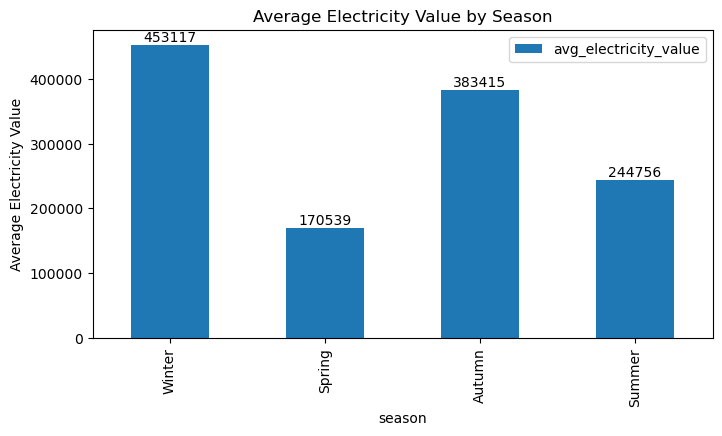

In [36]:
ax = query4_df.plot(
    x='season',
    y='avg_electricity_value',
    kind='bar',
    figsize=(8,4)
)

plt.title('Average Electricity Value by Season')
plt.ylabel('Average Electricity Value')

ax.bar_label(ax.containers[0], fmt='%.0f')

plt.show()

Winter has the highest average electricity value at 453,117. Spring has the lowest electricity value at 170,538. Autumn also has a relatively high electricity value. The results show that electricity value is not the same across the four seasons.

## Query 5: Conditions During Top 5% High-Price Events

The query examines weather conditions and electricity activity during Top 5% high-price events. Humidity is divided into three groups. Average electricity demand and electricity value are calculated for each group. The query then compares the results across the three humidity levels.

In [37]:
%%sql query5_result <<

SELECT
    CASE
        WHEN wh.humidity < 70 THEN 'Low humidity'
        WHEN wh.humidity < 80 THEN 'Medium humidity'
        ELSE 'High humidity'
    END AS humidity_band,
    COUNT(*) AS number_of_records,
    AVG(e.demand_gwh) AS avg_demand_gwh,
    AVG(e.total_electricity_value) AS avg_electricity_value

FROM electricity_observations e
INNER JOIN wind_humidity_observations wh
    ON e.date_id = wh.date_id
    AND e.location_id = wh.location_id
WHERE e.high_price_flag = 'Top 5%'
GROUP BY humidity_band;

 * sqlite:///a3_electricity_weather.db
Done.
Returning data to local variable query5_result


In [38]:
query5_df = query5_result.DataFrame()
query5_df

,humidity_band,number_of_records,avg_demand_gwh,avg_electricity_value
0,High humidity,169,3.422491,1.395065e+06
1,Low humidity,20,3.580050,1.167872e+06
2,Medium humidity,88,3.383432,1.337297e+06


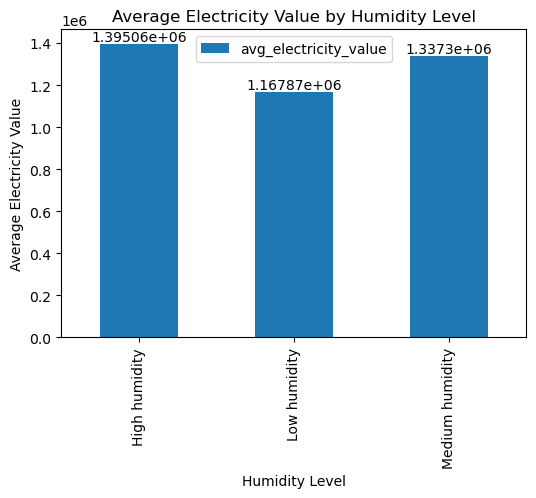

In [39]:
ax = query5_df.plot(
    x='humidity_band',
    y='avg_electricity_value',
    kind='bar',
    figsize=(6,4)
)

plt.title('Average Electricity Value by Humidity Level')
plt.xlabel('Humidity Level')
plt.ylabel('Average Electricity Value')
ax.bar_label(ax.containers[0])

plt.show()

Looking at the output, electricity value is higher in the High humidity group than in the other two groups. The average demand values do not change very much across the three groups. Humidity seems to have a clearer pattern with electricity value than with demand.

## Query 6: Monthly Trends in Electricity Demand and Electricity Value

The query is used to look at how electricity demand and electricity value change over time. The data are grouped by year and month. Then average electricity demand, average electricity value, and maximum electricity value are calculated for each month. The monthly results are then placed in time order.

In [40]:
%%sql query6_result <<

SELECT
    d.year,
    d.month,
    d.year || '-' || d.month AS year_month,
    COUNT(*) AS number_of_records,
    ROUND(AVG(e.demand_gwh), 2) AS avg_demand_gwh,
    ROUND(AVG(e.total_electricity_value), 2) AS avg_electricity_value,
    ROUND(MAX(e.total_electricity_value), 2) AS max_electricity_value
FROM electricity_observations AS e

INNER JOIN dates AS d
    ON e.date_id = d.date_id

GROUP BY d.year, d.month
ORDER BY d.year, d.month;

 * sqlite:///a3_electricity_weather.db
Done.
Returning data to local variable query6_result


In [41]:
query6_df = query6_result.DataFrame()
query6_df.head(5)

,year,month,year_month,number_of_records,avg_demand_gwh,avg_electricity_value,max_electricity_value
0,2023,1,2023-1,155,1.59,206128.07,1369988.18
1,2023,2,2023-2,140,1.72,272040.43,1056288.05
2,2023,3,2023-3,155,1.67,271837.75,863235.89
3,2023,4,2023-4,150,1.63,168535.36,579324.28
4,2023,5,2023-5,155,1.86,148245.98,1102915.32


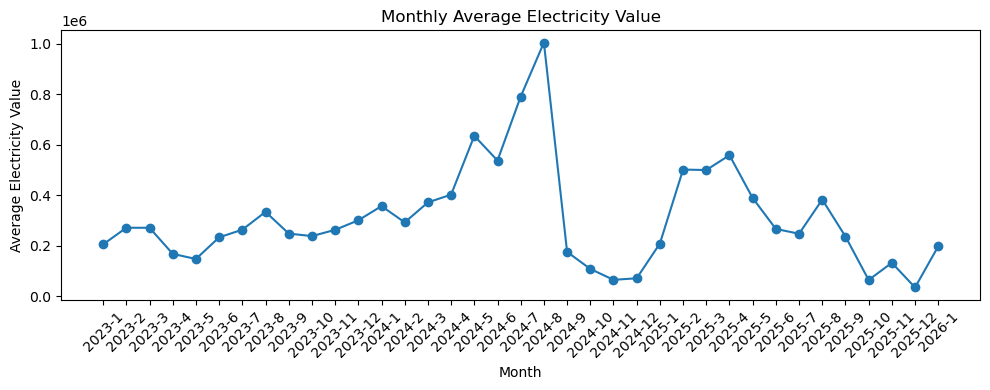

In [42]:
plt.figure(figsize=(10, 4))

plt.plot(
    query6_df['year_month'],
    query6_df['avg_electricity_value'],
    marker='o'
)

plt.title('Monthly Average Electricity Value')
plt.xlabel('Month')
plt.ylabel('Average Electricity Value')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

From the graph, electricity value changes over time. Many months have similar values. August 2024 has the highest value. The months around August are much lower. The graph shows that this increase is concentrated in a small part of the period rather than across the whole period.

# 5. DB Views

Two database views are created and tested below.

## DB View 1: Seasonal high-price weather summary
### Create View 1

This view focuses only on the records where the electricity value is in the top 5%. It joins the electricity, date, temperature, rainfall, wind, and humidity tables together. Then it groups the high-price records by season, so I can see which season has more high electricity price cases and what the weather conditions are like in those records.


In [43]:
%%sql

CREATE VIEW seasonal_high_price_weather_summary AS
SELECT
    d.season,
    COUNT(*) AS number_of_high_price_records,
    AVG(e.demand_gwh) AS avg_demand_gwh,
    AVG(e.total_electricity_value) AS avg_electricity_value,
    AVG(t.temp_mean) AS avg_temp_mean,
    AVG(r.rain) AS avg_rain,
    AVG(wh.wind_speed) AS avg_wind_speed,
    AVG(wh.humidity) AS avg_humidity
FROM electricity_observations AS e
INNER JOIN dates AS d
    ON e.date_id = d.date_id
INNER JOIN temperature_observations AS t
    ON e.date_id = t.date_id
   AND e.location_id = t.location_id
INNER JOIN rainfall_observations AS r
    ON e.date_id = r.date_id
   AND e.location_id = r.location_id
INNER JOIN wind_humidity_observations AS wh
    ON e.date_id = wh.date_id
   AND e.location_id = wh.location_id
WHERE e.high_price_flag = 'Top 5%'
GROUP BY d.season;

 * sqlite:///a3_electricity_weather.db
Done.


[]

### Test View 1

In [44]:
%%sql view1_result <<

SELECT *
FROM seasonal_high_price_weather_summary
ORDER BY
    CASE season
        WHEN 'Summer' THEN 1
        WHEN 'Autumn' THEN 2
        WHEN 'Winter' THEN 3
        WHEN 'Spring' THEN 4
    END;

 * sqlite:///a3_electricity_weather.db
Done.
Returning data to local variable view1_result


In [45]:
view1_df = view1_result.DataFrame()
view1_df

,season,number_of_high_price_records,avg_demand_gwh,avg_electricity_value,avg_temp_mean,avg_rain,avg_wind_speed,avg_humidity
0,Summer,30,3.629200,1.170008e+06,20.803333,3.400000,12.586667,77.166667
1,Autumn,101,3.496703,1.178254e+06,15.463366,3.347525,13.637624,78.356436
2,Winter,145,3.318097,1.524750e+06,10.811724,3.060000,13.537241,84.455172
3,Spring,1,4.577000,1.612912e+06,10.500000,1.900000,34.000000,69.000000


### Plot view 1

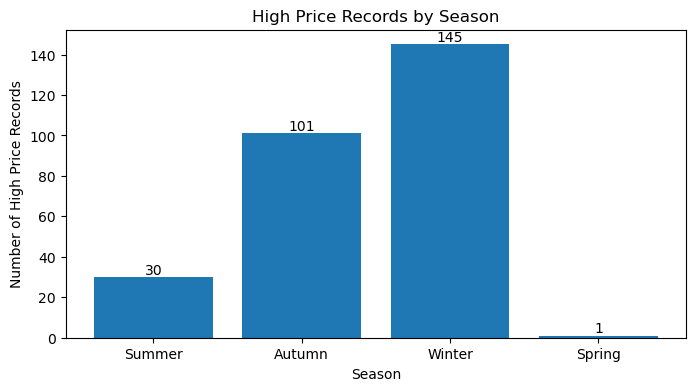

In [46]:
plt.figure(figsize=(8,4))

bars = plt.bar(
    view1_df['season'],
    view1_df['number_of_high_price_records']
)

plt.title('High Price Records by Season')
plt.xlabel('Season')
plt.ylabel('Number of High Price Records')
plt.bar_label(bars)
plt.show()

From the chart, winter has the most high-price records, with 145 records. Autumn is also high, with 101 records. Summer has much fewer high-price records, only 30, and spring has almost none, with only 1 record. This shows that high electricity value happens much more often in winter and autumn. It also matches the earlier result where winter had the highest average electricity value. A possible reason is that colder weather in winter may increase electricity use, especially for heating.

## DB View 2: Regional Electricity Summary

This view summarises electricity and weather data for each location. Average electricity demand, electricity value, temperature, and humidity are calculated for each place. This makes differences between locations to be seen more clearly.
### Create View 2

In [47]:
%%sql

CREATE VIEW regional_electricity_summary AS
SELECT
    l.place,
    COUNT(*) AS number_of_records,
    AVG(e.demand_gwh) AS avg_demand_gwh,
    AVG(e.total_electricity_value) AS avg_electricity_value,
    AVG(t.temp_mean) AS avg_temp_mean,
    AVG(wh.humidity) AS avg_humidity
FROM electricity_observations AS e

INNER JOIN locations AS l
    ON e.location_id = l.location_id

INNER JOIN temperature_observations AS t
    ON e.date_id = t.date_id
   AND e.location_id = t.location_id

INNER JOIN wind_humidity_observations AS wh
    ON e.date_id = wh.date_id
   AND e.location_id = wh.location_id

GROUP BY l.place;

 * sqlite:///a3_electricity_weather.db
Done.


[]

### Test View 2

In [48]:
%%sql view2_result <<

SELECT *
FROM regional_electricity_summary
ORDER BY avg_electricity_value DESC;

 * sqlite:///a3_electricity_weather.db
Done.
Returning data to local variable view2_result


In [49]:
view2_df = view2_result.DataFrame()
view2_df

,place,number_of_records,avg_demand_gwh,avg_electricity_value,avg_temp_mean,avg_humidity
0,"Penrose, Auckland",1107,3.594902,617427.719910,15.844535,79.066847
1,Hamilton,1107,1.824148,308599.329648,14.509575,80.663957
2,"Albany, Auckland",1107,1.719574,302271.019521,15.564770,80.350497
3,"Henderson, Auckland",1107,1.648165,283426.937245,15.282294,80.935863
4,Rotorua,1107,0.324238,53140.359693,13.135140,83.495032


### Plot view 2

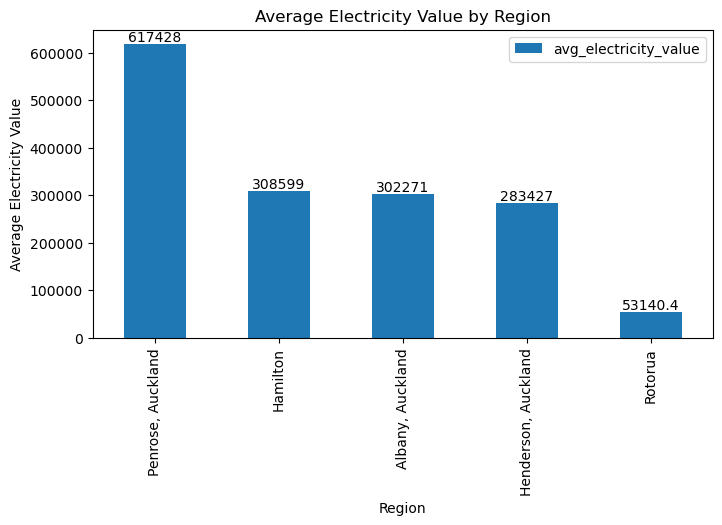

In [50]:
ax = view2_df.plot(
    x='place',
    y='avg_electricity_value',
    kind='bar',
    figsize=(8,4)
)

plt.title('Average Electricity Value by Region')
plt.xlabel('Region')
plt.ylabel('Average Electricity Value')
ax.bar_label(ax.containers[0])
plt.show()

From the table and graph, Penrose, Auckland has the highest average electricity value. Hamilton, Albany, Auckland, and Henderson, Auckland are closer to each other. Rotorua has the lowest value. The results show that electricity value is not the same across locations.